# **Project Name** - Strava Fitness Data Analysis

##### **Project Type** - EDA
##### **Contribution** - Individual


# **Project Summary -**
The project focuses on exploratory data analysis of a fitness activity dataset containing information about daily steps, calories, activity duration, activity intensity and sleep patterns.

The main purpose of this analysis is to understand the activity behaviour recorded in the dataset and identify meaningful patterns between different fitness-related variables. The analysis looks at daily activity levels, total steps, calories burned, active and sedentary minutes, sleep duration and sleep efficiency.

The dataset used for this analysis is the cleaned dataset prepared during the SQL stage of the project. Using the same cleaned dataset helps maintain consistency between the SQL analysis, Tableau dashboard and Python EDA.

Python libraries such as Pandas, NumPy, Matplotlib and Seaborn will be used for data loading, data understanding, data cleaning, visualization and exploratory analysis.

The analysis will begin by understanding the structure of the dataset, checking its rows, columns, data types, duplicate values and missing values. After that, the variables will be explored and the data will be prepared for visualization.

Different types of charts will then be used to study individual variables as well as relationships between variables. The analysis will include activity trends, activity levels, steps, calories, activity intensity and sleep-related patterns.

The final objective is to convert the raw fitness records into simple and understandable insights that can help in understanding user activity behaviour and identifying areas where a fitness platform could improve user engagement and activity tracking.

# **Problem Statement**
The dataset contains daily fitness and sleep-related information recorded for users. The objective is to explore this data and understand patterns in physical activity, including total steps, calories, active minutes, sedentary minutes and activity intensity.

The analysis also aims to study whether activity behaviour differs across activity levels and day types, and to explore the relationship between physical activity and sleep-related measures.

#### *Business Objective**
The business objective is to understand user activity behaviour from the available fitness data and identify patterns that can help a fitness platform improve user engagement.

The analysis will focus on identifying differences between activity levels, understanding daily activity patterns, comparing active and sedentary time, and exploring the relationship between physical activity and sleep. These insights can be used to support better activity tracking, user segmentation and personalised fitness goals.

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:

df = pd.read_csv("Strava_Tableau_Dashboard_Data.csv")

df

,Id,activity_date,total_steps,calories,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,activity_level,activity_intensity_segment,day_type,total_minutes_asleep,total_time_in_bed,sleep_efficiency,sleep_segment
0,1503960366,12-04-2016,13162,1985,25,13,328,728,High Activity,Moderate Very-Active,Weekday,327.0,346.0,94.5,Less than 6 Hours
1,1503960366,13-04-2016,10735,1797,21,19,217,776,High Activity,Moderate Very-Active,Weekday,384.0,407.0,94.3,6-8 Hours
2,1503960366,14-04-2016,10460,1776,30,11,181,1218,High Activity,High Very-Active,Weekday,NaN,NaN,NaN,More than 8 Hours
3,1503960366,15-04-2016,9762,1745,29,34,209,726,Moderate Activity,Moderate Very-Active,Weekday,412.0,442.0,93.2,6-8 Hours
4,1503960366,16-04-2016,12669,1863,36,10,221,773,High Activity,High Very-Active,Weekend,340.0,367.0,92.6,Less than 6 Hours
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,08-05-2016,10686,2847,17,4,245,1174,High Activity,Moderate Very-Active,Weekend,NaN,NaN,NaN,More than 8 Hours
936,8877689391,09-05-2016,20226,3710,73,19,217,1131,High Activity,High Very-Active,Weekday,NaN,NaN,NaN,More than 8 Hours
937,8877689391,10-05-2016,10733,2832,18,11,224,1187,High Activity,Moderate Very-Active,Weekday,NaN,NaN,NaN,More than 8 Hours
938,8877689391,11-05-2016,21420,3832,88,12,213,1127,High Activity,High Very-Active,Weekday,NaN,NaN,NaN,More than 8 Hours


### Understanding the Dataset

In [3]:
df.shape

(940, 15)

### Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          940 non-null    int64  
 1   activity_date               940 non-null    str    
 2   total_steps                 940 non-null    int64  
 3   calories                    940 non-null    int64  
 4   very_active_minutes         940 non-null    int64  
 5   fairly_active_minutes       940 non-null    int64  
 6   lightly_active_minutes      940 non-null    int64  
 7   sedentary_minutes           940 non-null    int64  
 8   activity_level              940 non-null    str    
 9   activity_intensity_segment  940 non-null    str    
 10  day_type                    940 non-null    str    
 11  total_minutes_asleep        410 non-null    float64
 12  total_time_in_bed           410 non-null    float64
 13  sleep_efficiency            410 non-null    fl

### Column Names

In [5]:
df.columns

Index(['Id', 'activity_date', 'total_steps', 'calories', 'very_active_minutes',
       'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes',
       'activity_level', 'activity_intensity_segment', 'day_type',
       'total_minutes_asleep', 'total_time_in_bed', 'sleep_efficiency',
       'sleep_segment'],
      dtype='str')

### Duplicate Values

In [6]:


df.duplicated().sum()

np.int64(0)

### Missing Values/Null Values

In [7]:
df.isnull().sum()

Id                              0
activity_date                   0
total_steps                     0
calories                        0
very_active_minutes             0
fairly_active_minutes           0
lightly_active_minutes          0
sedentary_minutes               0
activity_level                  0
activity_intensity_segment      0
day_type                        0
total_minutes_asleep          530
total_time_in_bed             530
sleep_efficiency              530
sleep_segment                   0
dtype: int64

### Visualizing missing values

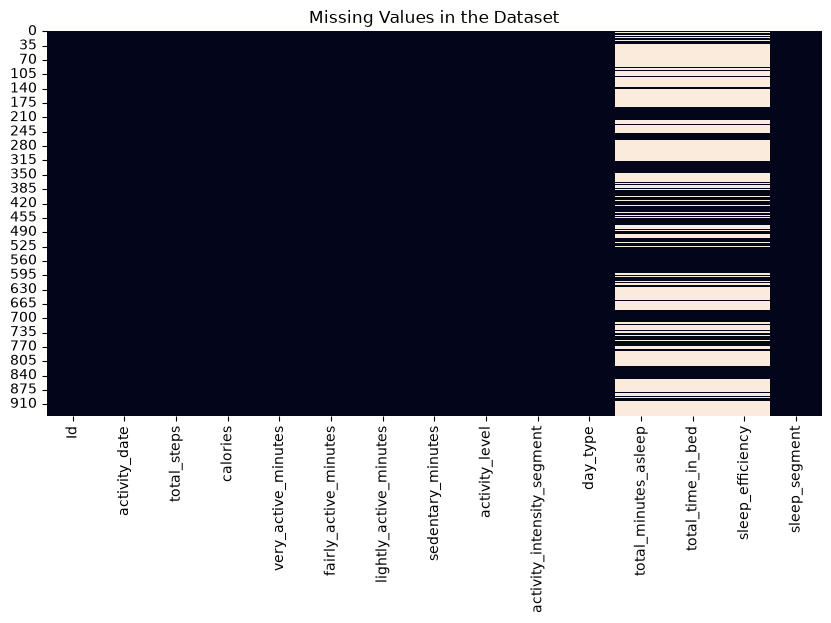

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in the Dataset")
plt.show()

### What did you know about your dataset?

The dataset contains 940 rows and 15 columns. Most of the columns do not have any missing values. However, `total_minutes_asleep`, `total_time_in_bed`, and `sleep_efficiency` contain a considerable number of missing values. These missing values are mainly related to sleep information, while the activity-related variables are complete.

There are no duplicate records in the dataset. For now, the missing values will not be removed or replaced, as they may be useful for understanding the availability of sleep-related information in the dataset.

## 2. Understanding Your Variables

In [9]:
# Dataset Columns

df.columns

Index(['Id', 'activity_date', 'total_steps', 'calories', 'very_active_minutes',
       'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes',
       'activity_level', 'activity_intensity_segment', 'day_type',
       'total_minutes_asleep', 'total_time_in_bed', 'sleep_efficiency',
       'sleep_segment'],
      dtype='str')

In [10]:
df.describe()

,Id,total_steps,calories,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,total_minutes_asleep,total_time_in_bed,sleep_efficiency
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,410.000000,410.000000,410.000000
mean,4.855407e+09,7637.910638,2303.609574,21.164894,13.564894,192.812766,991.210638,419.173171,458.482927,91.646098
std,2.424805e+09,5087.150742,718.166862,32.844803,19.987404,109.174700,301.267437,118.635918,127.455140,8.729549
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,58.000000,61.000000,49.800000
25%,2.320127e+09,3789.750000,1828.500000,0.000000,0.000000,127.000000,729.750000,361.000000,403.750000,91.200000
50%,4.445115e+09,7405.500000,2134.000000,4.000000,6.000000,199.000000,1057.500000,432.500000,463.000000,94.300000
75%,6.962181e+09,10727.000000,2793.250000,32.000000,19.000000,264.000000,1229.500000,490.000000,526.000000,96.100000
max,8.877689e+09,36019.000000,4900.000000,210.000000,143.000000,518.000000,1440.000000,796.000000,961.000000,100.000000


### Variables Description
The dataset contains variables related to daily physical activity, calorie expenditure, activity intensity and sleep patterns.

- **Id:** Unique identifier for each user.
- **activity_date:** Date on which the activity was recorded.
- **total_steps:** Total number of steps recorded in a day.
- **calories:** Total calories burned during the day.
- **very_active_minutes:** Minutes spent in very high-intensity activity.
- **fairly_active_minutes:** Minutes spent in fairly active physical activity.
- **lightly_active_minutes:** Minutes spent in light physical activity.
- **sedentary_minutes:** Minutes spent in sedentary activity.
- **activity_level:** Categorizes the user's overall activity level as Low, Moderate or High.
- **activity_intensity_segment:** Categorizes activity intensity into different intensity segments.
- **day_type:** Indicates the type of day based on the activity date.
- **total_minutes_asleep:** Total number of minutes the user was asleep.
- **total_time_in_bed:** Total time spent in bed.
- **sleep_efficiency:** Represents the efficiency of sleep based on time asleep compared with time in bed.
- **sleep_segment:** Categorizes users based on their sleep duration.

### Check Unique Values for each variable.

In [11]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


Id:
[1503960366 1624580081 1644430081 1844505072 1927972279 2022484408
 2026352035 2320127002 2347167796 2873212765 3372868164 3977333714
 4020332650 4057192912 4319703577 4388161847 4445114986 4558609924
 4702921684 5553957443 5577150313 6117666160 6290855005 6775888955
 6962181067 7007744171 7086361926 8053475328 8253242879 8378563200
 8583815059 8792009665 8877689391]

activity_date:
<ArrowStringArray>
['12-04-2016', '13-04-2016', '14-04-2016', '15-04-2016', '16-04-2016',
 '17-04-2016', '18-04-2016', '19-04-2016', '20-04-2016', '21-04-2016',
 '22-04-2016', '23-04-2016', '24-04-2016', '25-04-2016', '26-04-2016',
 '27-04-2016', '28-04-2016', '29-04-2016', '30-04-2016', '01-05-2016',
 '02-05-2016', '03-05-2016', '04-05-2016', '05-05-2016', '06-05-2016',
 '07-05-2016', '08-05-2016', '09-05-2016', '10-05-2016', '11-05-2016',
 '12-05-2016']
Length: 31, dtype: str

total_steps:
[13162 10735 10460  9762 12669  9705 13019 15506 10544  9819 12764 14371
 10039 15355 13755 18134 13154 11181 14

## 3. Data Wrangling

In [12]:
df['activity_date'] = pd.to_datetime(df['activity_date'], format='%d-%m-%Y')

In [13]:
df.dtypes

Id                                     int64
activity_date                 datetime64[us]
total_steps                            int64
calories                               int64
very_active_minutes                    int64
fairly_active_minutes                  int64
lightly_active_minutes                 int64
sedentary_minutes                      int64
activity_level                           str
activity_intensity_segment               str
day_type                                 str
total_minutes_asleep                 float64
total_time_in_bed                    float64
sleep_efficiency                     float64
sleep_segment                            str
dtype: object

In [14]:
df['activity_date'].isnull().sum()

np.int64(0)

### What all manipulations have you done and insights you found?

The dataset was already cleaned and prepared before starting the Python EDA. During the data wrangling stage, the activity_date column was converted from text format to a proper datetime format so that it can be used correctly for date-based analysis and visualizations.

No duplicate records were found in the dataset. The missing values in the sleep-related columns were retained because they represent unavailable sleep information rather than values that should be removed. No missing values were found in the activity_date column after conversion.

## 4. Data Visualization, Storytelling & Experimenting with Charts: Understand the Relationships Between Variables

### Chart 1: Daily Steps Trend

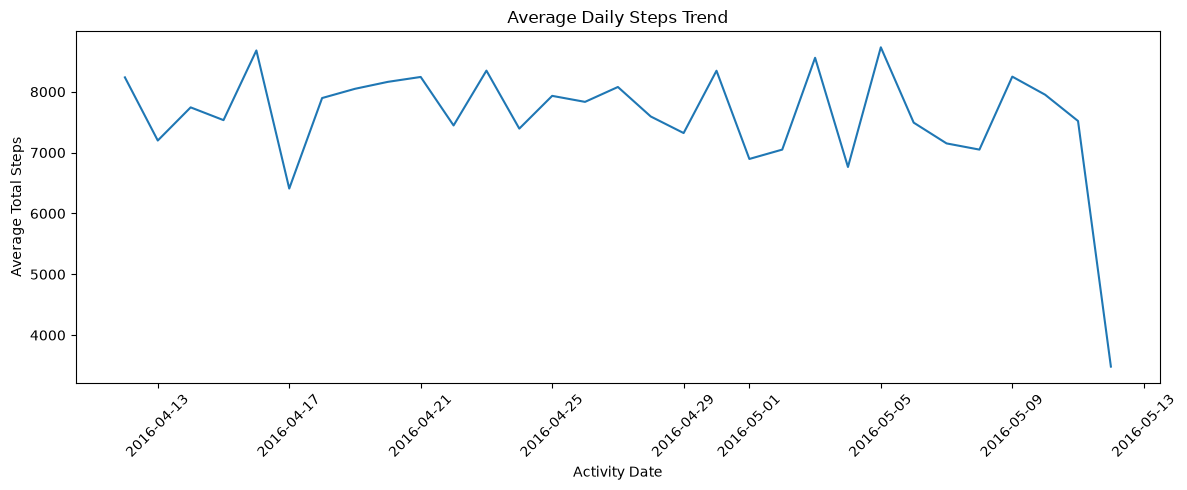

In [16]:
daily_steps = df.groupby('activity_date')['total_steps'].mean().reset_index()

daily_steps = daily_steps.sort_values('activity_date')

plt.figure(figsize=(12, 5))

plt.plot(daily_steps['activity_date'], daily_steps['total_steps'])

plt.title('Average Daily Steps Trend')
plt.xlabel('Activity Date')
plt.ylabel('Average Total Steps')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 1 Interpretation

**1. Why did you pick the specific chart?**

A line chart was selected because the data represents activity recorded over different dates. It helps us see how the average number of daily steps changes over the recorded period.


**2. What is/are the insight(s) found from the chart?**

The average daily steps mostly remained between around 7,000 and 8,500 steps. There are some fluctuations from day to day, with a few noticeable increases and decreases. The final date shows a sharp fall in the average number of steps compared with the previous days.


**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

The insights can help Strava understand the general activity pattern of its users and identify days when activity levels are lower. This can be useful for encouraging users to stay active through reminders, challenges or activity goals. The sharp decrease on the final date may indicate lower activity or incomplete data for that day, so it should be considered carefully before making decisions.

### Chart 2: Average Steps by Activity Level

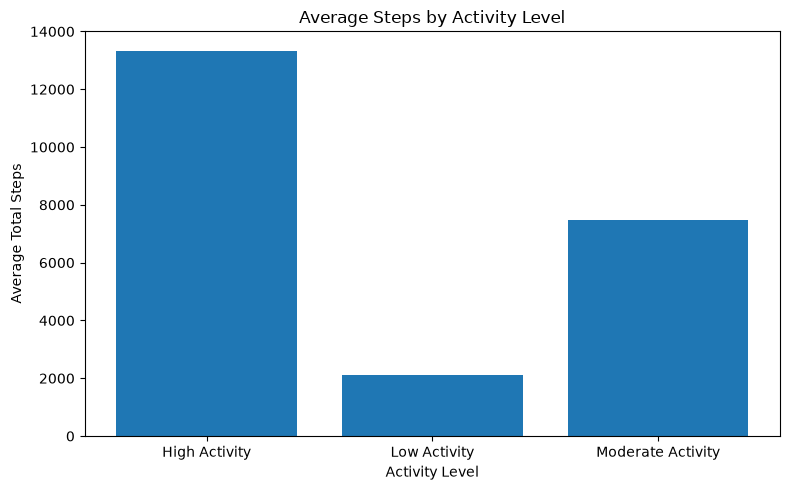

In [17]:
activity_steps = df.groupby('activity_level')['total_steps'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(activity_steps['activity_level'], activity_steps['total_steps'])

plt.title('Average Steps by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Total Steps')

plt.tight_layout()
plt.show()

### Chart 2 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average number of steps across different activity levels. It makes it easy to compare the three categories: Low Activity, Moderate Activity and High Activity.


**2. What is/are the insight(s) found from the chart?**

The chart shows a clear difference in average steps across the three activity levels. High Activity has the highest average at around 13,300 steps, while Moderate Activity is around 7,500 steps. Low Activity has the lowest average at around 2,100 steps.


**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

These insights can help Strava understand the difference between users with different activity levels. Users in the Low Activity group may be a useful target for engagement through challenges, reminders and achievable step goals. Encouraging these users to become more active could improve their engagement with the platform.

### Chart 3: Total Steps vs Calories

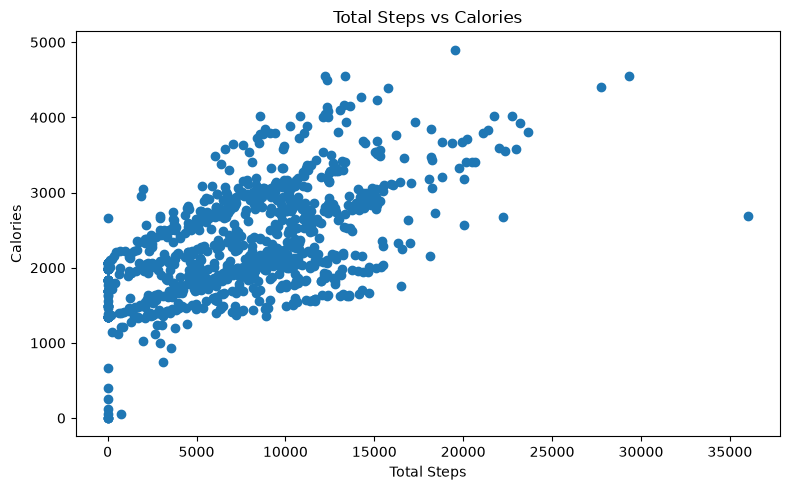

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df['total_steps'], df['calories'])

plt.title('Total Steps vs Calories')
plt.xlabel('Total Steps')
plt.ylabel('Calories')

plt.tight_layout()
plt.show()

### Chart 3 Interpretation

**1. Why did you pick the specific chart?**

A scatter plot was selected to understand the relationship between the total number of steps and calories burned. It helps us see whether an increase in steps is generally associated with an increase in calories.

**2. What is/are the insight(s) found from the chart?**

The chart shows a positive relationship between total steps and calories. In general, records with a higher number of steps also show higher calories burned. However, the points are spread out, which means that calories are also affected by other factors and do not depend only on the number of steps.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

This insight can help Strava show users how their activity level is related to calorie expenditure. It can also support features such as activity goals and progress tracking. However, the variation in the data shows that steps alone may not be enough to explain calorie expenditure, so other activity factors should also be considered.

### Chart 4: Sleep Duration vs Total Steps

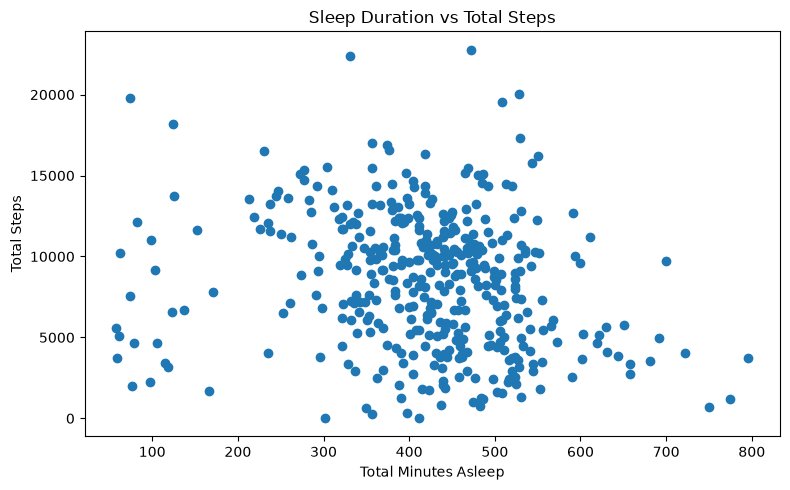

In [19]:
sleep_steps = df.dropna(subset=['total_minutes_asleep', 'total_steps'])

plt.figure(figsize=(8, 5))

plt.scatter(sleep_steps['total_minutes_asleep'], sleep_steps['total_steps'])

plt.title('Sleep Duration vs Total Steps')
plt.xlabel('Total Minutes Asleep')
plt.ylabel('Total Steps')

plt.tight_layout()
plt.show()

### Chart 4 Interpretation

**1. Why did you pick the specific chart?**

A scatter plot was selected to understand whether there is any visible relationship between total minutes asleep and total steps. It helps compare sleep duration with daily physical activity.

**2. What is/are the insight(s) found from the chart?**

The chart shows that there is no clear strong relationship between sleep duration and total steps. The data points are widely spread across different sleep durations and step counts. This suggests that sleeping for more or fewer minutes does not necessarily result in a higher or lower number of steps.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

This insight can help Strava understand that sleep duration alone may not be a strong indicator of a user's daily activity level. Therefore, user engagement and activity recommendations should consider other factors such as activity intensity and step count instead of relying only on sleep duration. The wide variation also shows that users have different activity patterns, which can be considered when designing personalized fitness features.

### Chart 5: Average Calories by Activity Level

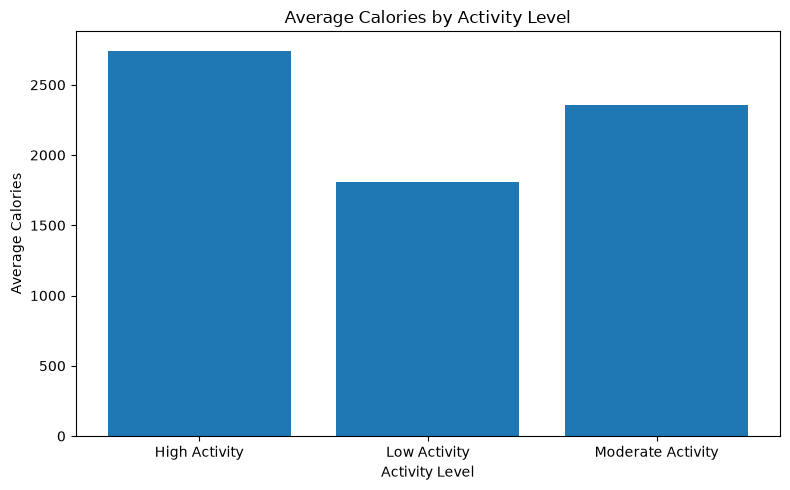

In [20]:
activity_calories = df.groupby('activity_level')['calories'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(activity_calories['activity_level'], activity_calories['calories'])

plt.title('Average Calories by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Calories')

plt.tight_layout()
plt.show()

### Chart 5 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average calories burned across different activity levels. Since the activity levels are categories, a bar chart makes the difference between them easy to understand.

**2. What is/are the insight(s) found from the chart?**

The High Activity group has the highest average calorie expenditure, at around 2,700 calories. The Moderate Activity group follows with around 2,350 calories, while the Low Activity group has the lowest average at around 1,800 calories. This shows that higher activity levels are associated with higher average calories burned.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

These insights can help Strava understand the relationship between activity level and calorie expenditure. The lower calorie expenditure among Low Activity users can indicate an opportunity to encourage these users through achievable activity goals, challenges and reminders. This could help improve user engagement and encourage users to become more active.

### Chart 6: Average Active Minutes by Activity Level

In [21]:
activity_minutes = df.groupby('activity_level')[
    ['very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes']
].mean().reset_index()

activity_minutes

,activity_level,very_active_minutes,fairly_active_minutes,lightly_active_minutes
0,High Activity,48.544554,27.372937,237.844884
1,Low Activity,2.336634,1.973597,88.214521
2,Moderate Activity,13.407186,11.553892,246.850299


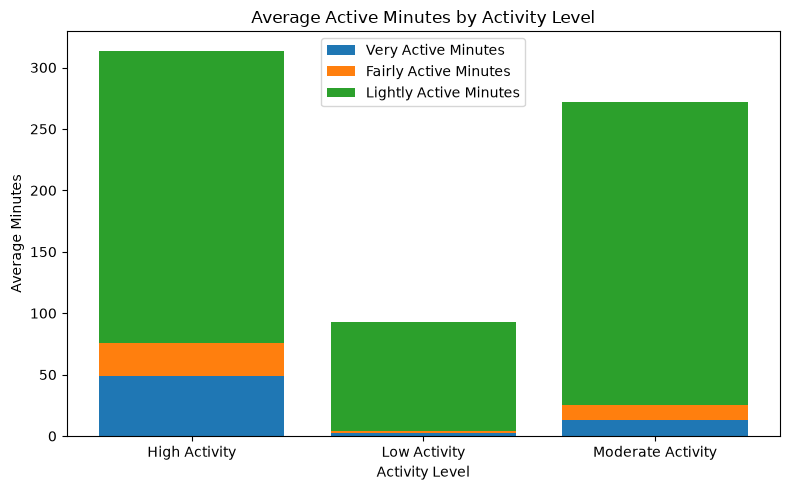

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(activity_minutes['activity_level'], activity_minutes['very_active_minutes'],
        label='Very Active Minutes')
plt.bar(activity_minutes['activity_level'], activity_minutes['fairly_active_minutes'],
        bottom=activity_minutes['very_active_minutes'],
        label='Fairly Active Minutes')
plt.bar(activity_minutes['activity_level'],
        activity_minutes['lightly_active_minutes'],
        bottom=activity_minutes['very_active_minutes'] + activity_minutes['fairly_active_minutes'],
        label='Lightly Active Minutes')

plt.title('Average Active Minutes by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Minutes')
plt.legend()

plt.tight_layout()
plt.show()

### Chart 6: Average Active Minutes by Activity Level

**1. Why did you pick the specific chart?**

A stacked bar chart was selected to compare the average time spent in different activity intensities across Low, Moderate, and High Activity levels. It helps show both the total active time and how that time is distributed among very active, fairly active, and lightly active minutes.

**2. What is/are the insight(s) found from the chart?**

The High Activity group records the highest average time across activity intensities, with approximately 48.55 very active minutes, 27.37 fairly active minutes, and 237.85 lightly active minutes. The Moderate Activity group has a similar amount of lightly active time at approximately 246.05 minutes, but substantially fewer very and fairly active minutes. The Low Activity group has considerably lower active time across all three categories, particularly in very and fairly active minutes.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

These insights can help improve user engagement by identifying differences in activity behaviour across user groups. Low Activity users may benefit from personalized reminders, achievable activity goals, and challenges designed to gradually increase their active time. The relatively low participation in higher-intensity activities among Low and Moderate Activity users may represent an opportunity for targeted engagement strategies. If these users remain inactive, it could lead to lower engagement and reduced long-term usage of the fitness platform.

### Chart 7: Sleep Efficiency vs Total Time in Bed

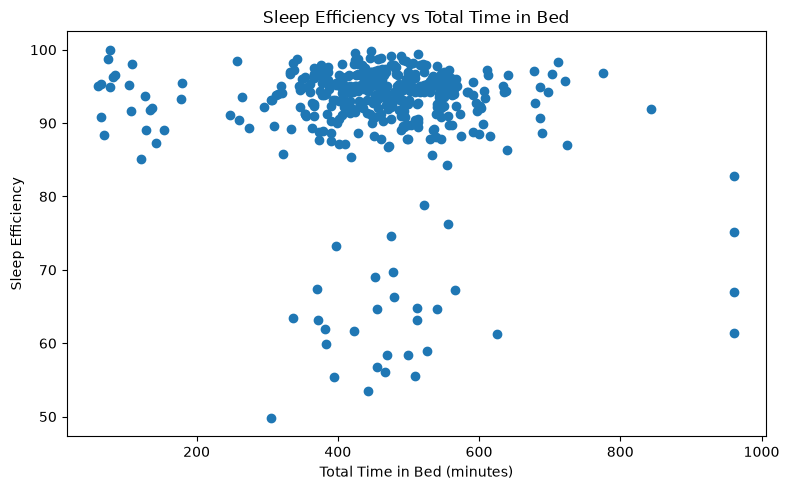

In [23]:
sleep_efficiency = df.dropna(
    subset=['total_time_in_bed', 'sleep_efficiency']
)

plt.figure(figsize=(8, 5))

plt.scatter(
    sleep_efficiency['total_time_in_bed'],
    sleep_efficiency['sleep_efficiency']
)

plt.title('Sleep Efficiency vs Total Time in Bed')
plt.xlabel('Total Time in Bed (minutes)')
plt.ylabel('Sleep Efficiency')

plt.tight_layout()
plt.show()

### Chart 7 Interpretation

**1. Why did you pick the specific chart?**

A scatter plot was selected to understand the relationship between total time spent in bed and sleep efficiency. It helps identify whether spending more time in bed is associated with better sleep efficiency and makes it easier to observe the overall pattern and variation in the data.

**2. What is/are the insight(s) found from the chart?**

The chart shows that sleep efficiency varies considerably across different amounts of time spent in bed. There is no strong or consistent upward relationship visible, indicating that spending more time in bed does not necessarily result in higher sleep efficiency. Most observations are concentrated around moderate to high sleep durations, while efficiency still varies within this range.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

Yes, these insights can help create a positive business impact for a fitness or health-tracking platform. The findings suggest that simply increasing time in bed may not be sufficient to improve sleep quality, so the platform could provide users with recommendations focused on sleep efficiency and healthy sleep habits rather than only sleep duration. This can improve the usefulness of personalized sleep insights and encourage better user engagement. No direct negative growth is indicated by this chart, although relying only on time spent in bed as a measure of sleep quality could lead to ineffective recommendations.

### Chart 8: Average Sleep Efficiency by Sleep Segment

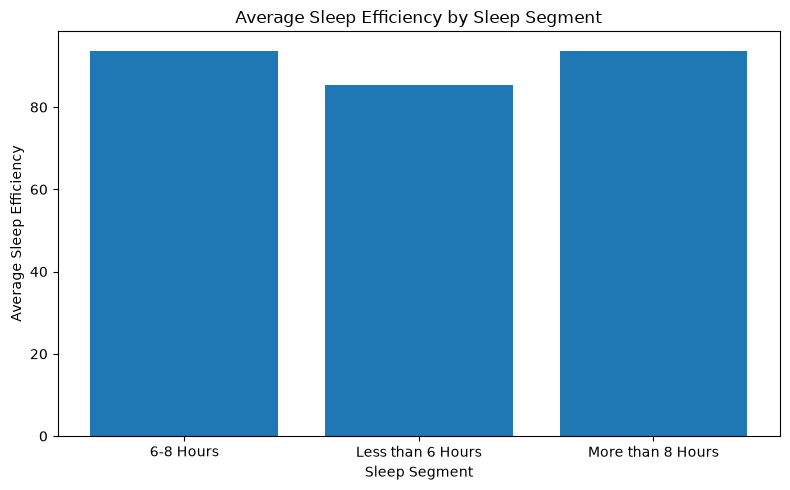

In [24]:
sleep_segment_efficiency = df.groupby('sleep_segment')['sleep_efficiency'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sleep_segment_efficiency['sleep_segment'],
    sleep_segment_efficiency['sleep_efficiency']
)

plt.title('Average Sleep Efficiency by Sleep Segment')
plt.xlabel('Sleep Segment')
plt.ylabel('Average Sleep Efficiency')

plt.tight_layout()
plt.show()

### Chart 8 Interpretation

**1. Why did you pick this specific chart?**

A bar chart was selected to compare the average sleep efficiency across the three sleep segments. It makes it easy to see how sleep efficiency differs between users based on their sleep duration.

**2. What is/are the insight(s) found from the chart?**

The chart shows that users sleeping less than 6 hours have the lowest average sleep efficiency. Users sleeping between 6–8 hours and more than 8 hours have higher and fairly similar sleep efficiency.

This suggests that very short sleep duration may be associated with lower sleep efficiency in the dataset.

**3. Will the gained insights help creating a positive business impact?**

Yes. This insight can help a wellness platform encourage users who regularly sleep for less than 6 hours to improve their sleep routine. Sleep-related reminders, personalised sleep goals and simple recommendations could help improve user engagement with wellness features.

### Chart 9: Average Sleep Efficiency by Activity Level

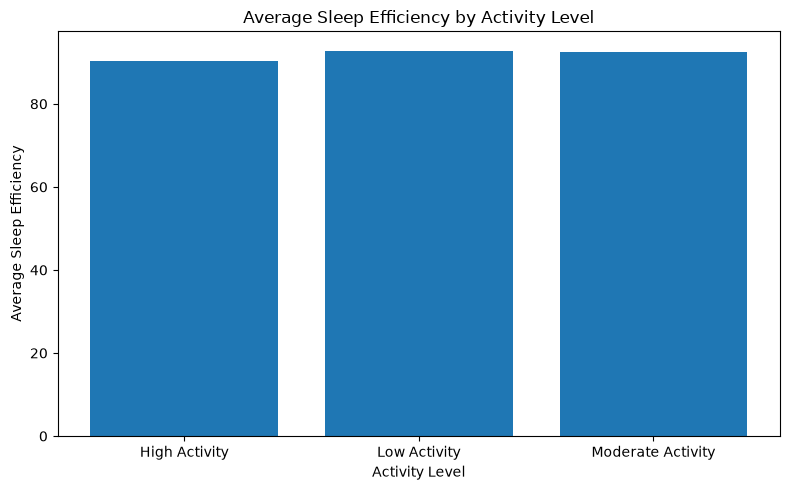

In [25]:
activity_sleep_efficiency = df.groupby('activity_level')['sleep_efficiency'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    activity_sleep_efficiency['activity_level'],
    activity_sleep_efficiency['sleep_efficiency']
)

plt.title('Average Sleep Efficiency by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Sleep Efficiency')

plt.tight_layout()
plt.show()

###  Chart 9 Interpretation

**1. Why did you pick this specific chart?**

A bar chart was selected to compare the average sleep efficiency across different activity levels. It provides a clear comparison of sleep efficiency among High, Moderate, and Low Activity groups.

**2. What is/are the insight(s) found from the chart?**

The chart shows that average sleep efficiency is relatively high across all three activity levels. The Low Activity group has the highest average sleep efficiency, while the High Activity group has the lowest. However, the differences between the groups are relatively small.

This suggests that activity level alone does not have a strong relationship with sleep efficiency in this dataset.

**3. Will the gained insights help creating a positive business impact?**

Yes. The insight suggests that sleep efficiency should not be evaluated based only on a user's activity level. A wellness platform could consider additional factors such as sleep duration, time in bed, and daily activity patterns when providing personalised recommendations.

### Chart 10: Average Sedentary Minutes by Activity Level

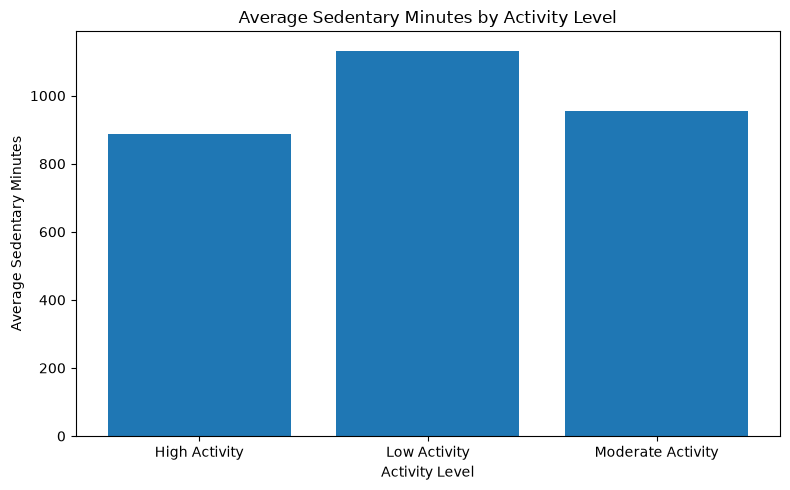

In [26]:
sedentary_activity = df.groupby('activity_level')['sedentary_minutes'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sedentary_activity['activity_level'],
    sedentary_activity['sedentary_minutes']
)

plt.title('Average Sedentary Minutes by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Sedentary Minutes')

plt.tight_layout()
plt.show()

### Chart 10 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average sedentary minutes across different activity levels. This makes it easy to identify differences in sedentary behaviour between High, Moderate, and Low Activity users.

**2. What is/are the insight(s) found from the chart?**

The Low Activity group has the highest average sedentary minutes, followed by the Moderate Activity group. The High Activity group has the lowest average sedentary minutes.

This indicates that users with higher overall activity levels tend to spend less time in sedentary activities, while users in the Low Activity group spend considerably more time sedentary.

**3. Will the gained insights help creating a positive business impact?**

Yes. These insights can help a fitness platform identify users who may benefit from interventions aimed at reducing sedentary behaviour. Features such as activity reminders, movement goals, and personalised notifications could encourage Low Activity users to take more frequent breaks from prolonged sedentary periods.

### Chart 11: Average Sleep Duration by Activity Level

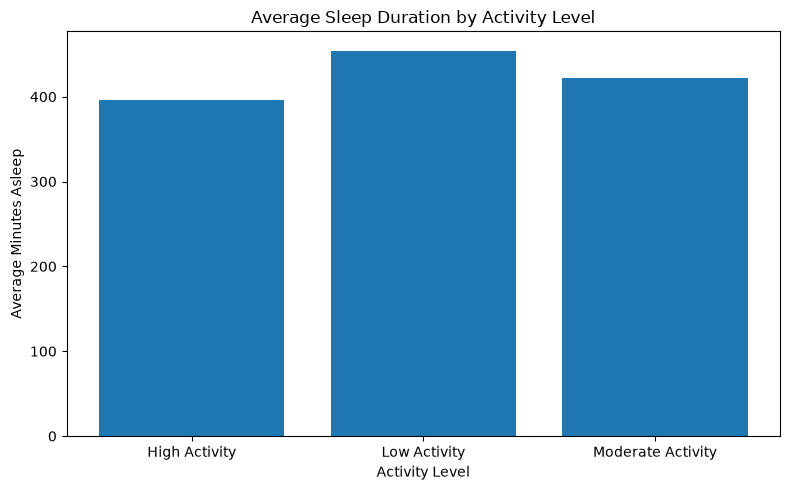

In [27]:
sleep_duration_activity = df.groupby('activity_level')['total_minutes_asleep'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sleep_duration_activity['activity_level'],
    sleep_duration_activity['total_minutes_asleep']
)

plt.title('Average Sleep Duration by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Minutes Asleep')

plt.tight_layout()
plt.show()

### Chart 11 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average sleep duration across different activity levels. It provides a clear comparison of how much time users spend asleep in the High, Moderate, and Low Activity groups.

**2. What is/are the insight(s) found from the chart?**

The Low Activity group has the highest average sleep duration, while the High Activity group has the lowest average sleep duration. The Moderate Activity group falls between the two.

This indicates that higher physical activity does not necessarily correspond to longer sleep duration in this dataset. Users with lower activity levels appear to spend more time asleep on average.

**3. Will the gained insights help creating a positive business impact?**

Yes. The insight can help a fitness platform understand that users with different activity levels may have different sleep patterns. Combining activity and sleep information can support more personalised recommendations instead of assuming that increasing activity will always result in longer sleep duration.

### Chart 12: Average Sleep Duration by Sleep Segment

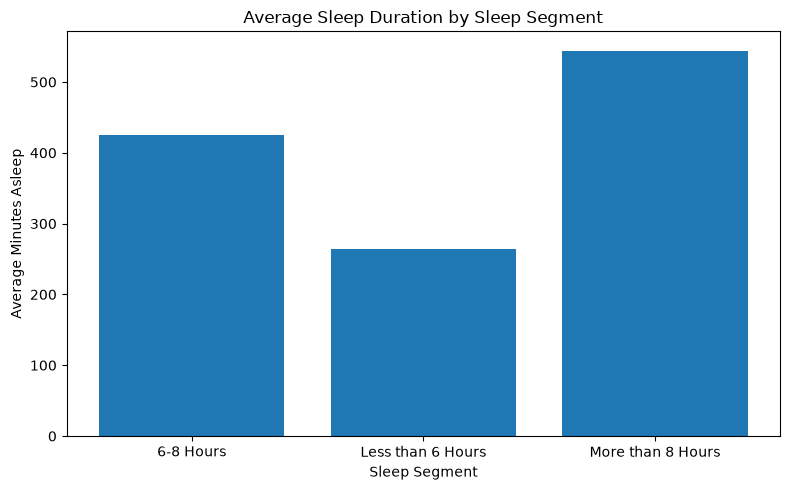

In [28]:
sleep_segment_duration = df.groupby('sleep_segment')['total_minutes_asleep'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sleep_segment_duration['sleep_segment'],
    sleep_segment_duration['total_minutes_asleep']
)

plt.title('Average Sleep Duration by Sleep Segment')
plt.xlabel('Sleep Segment')
plt.ylabel('Average Minutes Asleep')

plt.tight_layout()
plt.show()

### Chart 12 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average sleep duration across different sleep segments. It provides a simple and clear comparison of the amount of time users spend asleep within each sleep-duration category.

**2. What is/are the insight(s) found from the chart?**

The "More than 8 Hours" sleep segment has the highest average sleep duration, followed by the "6-8 Hours" segment. The "Less than 6 Hours" segment has the lowest average sleep duration.

The results show a clear difference in actual sleep duration across the three sleep segments, with users in the longer sleep category recording substantially more minutes asleep.

**3. Will the gained insights help creating a positive business impact?**

Yes. These insights can help a fitness platform understand users' sleep-duration patterns and identify users who may not be getting sufficient sleep. The platform could provide personalised sleep goals, reminders, and recommendations to encourage healthier sleep habits.

### Chart 13: Average Time in Bed by Sleep Segment

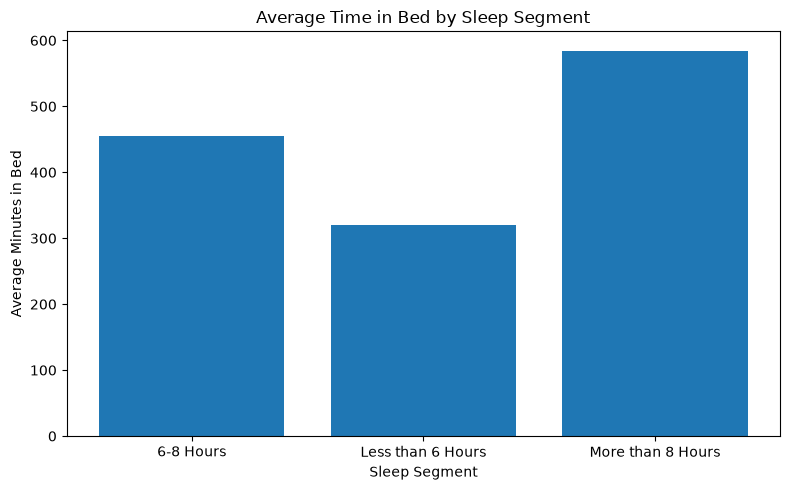

In [29]:
sleep_segment_bed = df.groupby('sleep_segment')['total_time_in_bed'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sleep_segment_bed['sleep_segment'],
    sleep_segment_bed['total_time_in_bed']
)

plt.title('Average Time in Bed by Sleep Segment')
plt.xlabel('Sleep Segment')
plt.ylabel('Average Minutes in Bed')

plt.tight_layout()
plt.show()

### Chart 13 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected to compare the average time spent in bed across different sleep segments. This makes it easy to identify differences in overall time spent in bed between the three sleep-duration groups.

**2. What is/are the insight(s) found from the chart?**

The "More than 8 Hours" sleep segment has the highest average time spent in bed, followed by the "6-8 Hours" segment. The "Less than 6 Hours" segment has the lowest average time in bed.

The pattern is similar to the average sleep duration observed in the previous chart, suggesting that users who sleep for longer durations also tend to spend more total time in bed.

**3. Will the gained insights help creating a positive business impact?**

Yes. This insight can help the fitness platform understand users' overall sleep patterns and identify users with shorter sleep durations. The platform could use this information to provide personalised sleep recommendations and encourage users to maintain healthier sleep routines.

### Chart 14: Average Sleep Efficiency by Activity Level

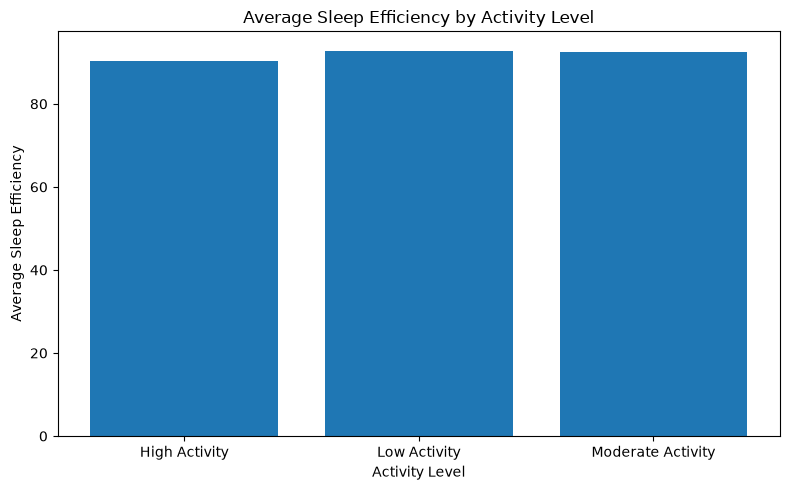

In [30]:
activity_sleep_efficiency = df.groupby('activity_level')['sleep_efficiency'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    activity_sleep_efficiency['activity_level'],
    activity_sleep_efficiency['sleep_efficiency']
)

plt.title('Average Sleep Efficiency by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Sleep Efficiency')

plt.tight_layout()
plt.show()

### Chart 14: Average Steps by Day Type

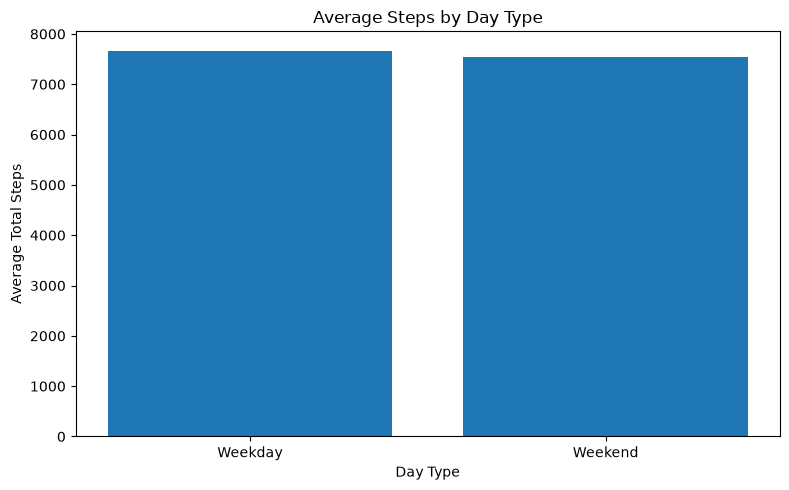

In [31]:
day_steps = df.groupby('day_type')['total_steps'].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    day_steps['day_type'],
    day_steps['total_steps']
)

plt.title('Average Steps by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Average Total Steps')

plt.tight_layout()
plt.show()

### Chart 14 Interpretation

**1. Why did you pick the specific chart?**

A bar chart was selected because it provides a clear comparison of the average number of steps between weekdays and weekends. It makes the difference in activity levels between the two day types easy to identify.

**2. What is/are the insight(s) found from the chart?**

The chart shows that the average number of steps is slightly higher on weekdays than on weekends. Weekday activity is approximately 7,600 steps on average, while weekend activity is approximately 7,500 steps. This indicates that users maintain relatively similar activity levels across both day types, with only a small decrease in activity during weekends.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

Yes, the insight can help in designing targeted engagement strategies. Since weekend activity is slightly lower than weekday activity, the platform could introduce weekend-specific challenges, reminders, or activity goals to encourage users to remain active. However, the difference is relatively small, so there is no strong evidence of a major negative activity pattern. The finding mainly highlights an opportunity to maintain or improve weekend engagement.

### Chart 15: Correlation Heatmap



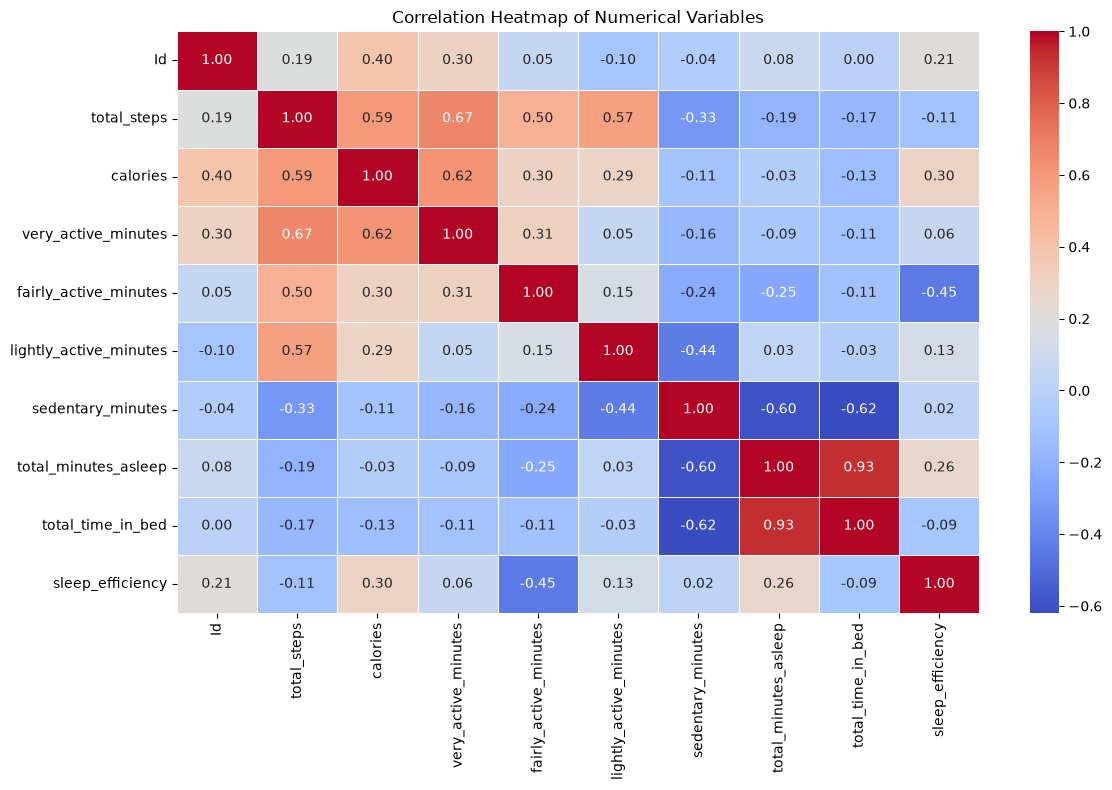

In [32]:
# Select numerical variables for correlation analysis
correlation_data = df.select_dtypes(include='number')

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### Chart 15 Interpretation

**1. Why did you pick the specific chart?**

A correlation heatmap was selected to provide an overall view of the relationships between numerical variables. It makes it easier to identify strong, moderate, and weak correlations across multiple variables at the same time.

**2. What is/are the insight(s) found from the chart?**

The heatmap shows which activity, calorie, and sleep-related variables have stronger relationships with each other. Strong positive correlations indicate that two variables tend to increase together, while negative correlations indicate an inverse relationship.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

The insights can help identify which user behaviours are most closely associated with activity and wellness outcomes. These relationships can support more targeted recommendations and engagement strategies. However, correlation does not necessarily imply causation, so the findings should be used as supporting evidence rather than definitive conclusions.

### Chart 16: Pairplot



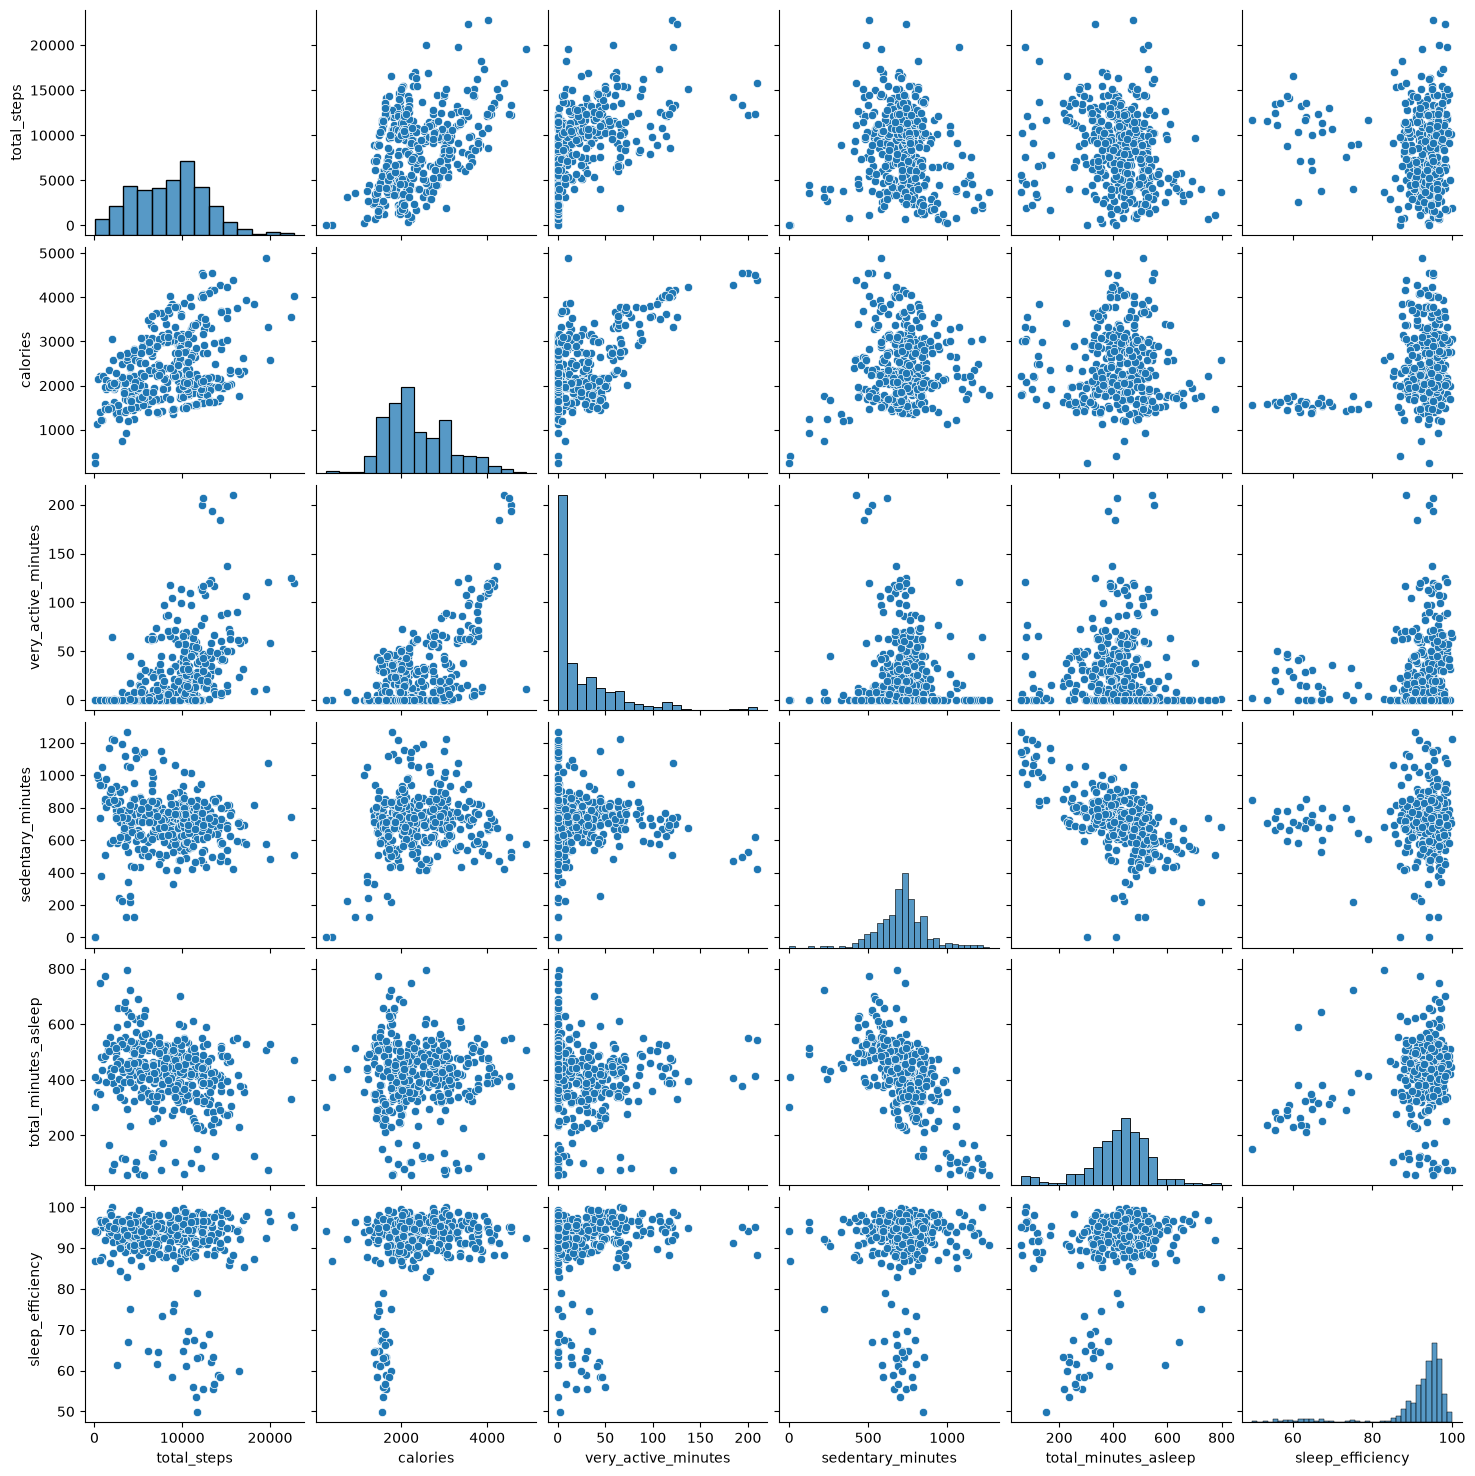

In [33]:
pairplot_data = df[
    [
        'total_steps',
        'calories',
        'very_active_minutes',
        'sedentary_minutes',
        'total_minutes_asleep',
        'sleep_efficiency'
    ]
].dropna()

sns.pairplot(
    pairplot_data
)

plt.show()

### Chart 16 Interpretation

**1. Why did you pick the specific chart?**

A pairplot was selected to examine the relationships and distributions of multiple numerical variables simultaneously. It helps identify positive and negative relationships, patterns, clusters, and potential outliers across activity, calorie, and sleep-related variables.

**2. What is/are the insight(s) found from the chart?**

The pairplot shows a clear positive relationship between total steps and calories, indicating that users who record more steps generally tend to burn more calories. Activity-related variables such as very active, fairly active, and lightly active minutes also show relationships with total steps and calories. Sedentary minutes generally show a weaker or negative relationship with activity measures. The sleep variables, particularly total minutes asleep and total time in bed, show a noticeable positive relationship with each other. Overall, the pairplot indicates that physical activity variables are more strongly related to calorie expenditure than the sleep-related variables.

**3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

Yes, these insights can support positive business impact by helping the platform understand which activity measures are most closely associated with calorie expenditure and overall user activity. This can be used to design personalized activity goals, challenges, and recommendations. The relatively weaker relationships between sleep variables and activity measures suggest that users' sleep patterns may not directly correspond to their physical activity levels, highlighting an opportunity for the platform to provide separate sleep and activity recommendations. No major negative growth pattern can be concluded from the pairplot alone.

## 5. Solution to Business Objective

Based on the EDA findings, the client can focus on increasing user engagement and encouraging healthier activity and sleep patterns through personalized recommendations. Users with low activity levels can be targeted with achievable step goals, reminders, and activity challenges. Since higher activity levels are associated with higher calorie expenditure, personalized activity goals can encourage users to become more active.

The platform can also promote weekend activity challenges because average steps are slightly lower on weekends. Separate sleep-focused recommendations can be provided to users with shorter sleep durations or lower sleep efficiency. Overall, combining activity tracking, personalized goals, reminders, and challenges can help improve user engagement and encourage healthier lifestyle habits.

## Conclusion

The exploratory data analysis provided useful insights into users' physical activity and sleep patterns. The dataset contains 940 records and 15 variables, with activity-related variables largely complete while some sleep-related variables contain missing values. No duplicate records were identified, and the missing sleep-related values were retained because they may provide useful information about the availability of sleep data.

The analysis showed that activity level is strongly associated with total steps and calorie expenditure. Higher activity levels generally correspond to more steps and higher average calories burned, while low activity users show considerably lower activity levels. Sleep duration and sleep efficiency showed comparatively weaker relationships with physical activity. The correlation heatmap and pair plot further helped identify relationships among the numerical variables.

These findings can help the client improve user engagement through personalized activity goals, challenges, reminders, and separate sleep-related recommendations. Overall, the analysis provides a data-driven understanding of user activity and sleep behavior and highlights opportunities for improving engagement and encouraging healthier lifestyle patterns.